### Chapter 3 - Computer Vision

**This week's exercise has 4 tasks, for a total of 10 points. Don't forget to submit your solutions to GitHub!**

In this chapter, we want you to become proficient at the following tasks:
- Building a modern PyTorch segmentation model
- Training a modern model on a real-world segmentation task and achieving passable results

**Note**: This is the last exercise concerning pure computer vision. Starting next week, we will begin with Natural Language Processing, i.e. text data. Therefore, don't worry too much if this exercise feels hard or if you can't complete all of it ;)

#### Chapter 3.5 - Segmentation

In previous tasks, we solved classification problems - we provide some input(s), typically an image, and get out a few numbers, which are the predicted pseudo-probabilities that our input belongs to some class, such as "tumor" or "no tumor". For this exercise, we will explore a new task that is extremely common in medical AI research and in clinical practice. This task is called segmentation. In segmentation, the goal is to go from an input image to one or several segmentations (also called *segmentation maps*) of that image. For the example of LiTS, this means that our input remains the same - a 256x256 image with 1 channel. However, our model outputs and targets are now different - they also have the shape 256x256 pixels, times the number of output classes, in our case 3 (background, liver, liver+tumor). Each 256x256 output is basically a map of which pixels in the original image belong to a certain class with what (pseudo-)probability. The training objective, in its simplest form, is also the same; Cross-Entropy Loss, but per pixel, instead of per-image.

To solve today's tasks, we will need to build ourselves a few new things that look almost the same as things we have already built.

**Task 1 (2 points)**: We will need a new Dataset class. It is the same as usual, except this time, when we return image and target in the getitem method, our target is now also a multi-dimensional tensor of size.

We will return two kinds of targets - class-index targets and one-hot encoded targets. Class-index targets you already know. Every pixel is assigned a class, which can be 0 for background, 1 for liver, and 2 for lesions. The corresponding tensor has the size $H * W$. One-hot encoded targets instead have size $C * H * W$ - each channel is one class (the 0th channel is background, etc.), and the values for each pixel in a channel are 1 if that pixel belongs to that class and 0 if not. We will need both later on - class-index targets because that is the input for the normal CrossEntropyLoss, and one-hot targets because we will use them in this format for our DiceLoss.

Since the "background" class has no segmentations, you will have to improvise them from the existing segmentations for this task.

Your dataset class should return both targets at the end of the \_\_getitem\_\_ method like this: `return image, c_targets, oh_targets`.

In [1]:
import numpy as np
import imageio.v2 as iio
from pyexpat import features

m = iio.imread("Clean_LiTS/test/segmentation-100_lesionmask_422.png")
print(np.unique(m))

viz = m * 255
iio.imwrite("viz.png", viz)

[0 1]


In [2]:
import torch
import torchvision.transforms.functional as ttf
import pandas as pd
import PIL
import torchvision.transforms as T



class LiTS_Segmentation_Dataset(torch.utils.data.Dataset):

    def __init__(self, csv: str, mode: str):

        self.csv = csv
        self.data = pd.read_csv(self.csv)
        self.mode = mode
        assert mode in ["train", "val", "test"] # has to be train, val, or test data - if not, assert throws an error


    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx: int):
        idx = int(idx)
        image_file = self.data.iloc[idx]["filename"]
        liver_file = self.data.iloc[idx][ "liver_segmentation"]
        tumor_file = self.data.iloc[idx][ "lesion_segmentation"]

        with PIL.Image.open(f"./Clean_LiTS/{self.mode}/{image_file}") as f:
            f = f.convert("L")
            image = ttf.pil_to_tensor(f)
        with PIL.Image.open(f"./Clean_LiTS/{self.mode}/{liver_file}") as f:
            f = f.convert("L")
            liver_mask = ttf.pil_to_tensor(f)
        with PIL.Image.open(f"./Clean_LiTS/{self.mode}/{tumor_file}") as f:
            f = f.convert("L")
            tumor_mask = ttf.pil_to_tensor(f)

        image = image.float()
        image -= image.min()
        max_val = image.max()
        if max_val > 0:
            image /= max_val


        c_targets = torch.zeros_like(liver_mask, dtype=torch.long)

        # liver = 1
        c_targets[liver_mask == 1] = 1

        # tumor = 2
        c_targets[tumor_mask == 1] = 2

        c_targets = c_targets.squeeze(0)

        oh_targets = torch.nn.functional.one_hot(c_targets, num_classes=3)
        oh_targets = oh_targets.permute(2, 0, 1).float()

        # We need both the class-index version for the cross-entropy loss and the one-hot version for our dice loss later
        return image, c_targets, oh_targets


In [3]:
from torch.utils.data import Dataset, DataLoader, Subset

train_dataset = LiTS_Segmentation_Dataset(csv = "./Clean_LiTS/train_classes.csv", mode="train")
val_dataset = LiTS_Segmentation_Dataset(csv = "./Clean_LiTS/val_classes.csv", mode="val")
test_dataset = LiTS_Segmentation_Dataset(csv = "./Clean_LiTS/test_classes.csv", mode="test")

batch_size = 14

train_dataloader = DataLoader(
    dataset = train_dataset,
    batch_size = batch_size,
    num_workers = 0,
    shuffle = True,
    drop_last = True
)

val_dataloader = DataLoader(
    dataset = val_dataset,
    batch_size = batch_size,
    num_workers = 0,
    shuffle = True,
    drop_last = True
)

test_dataloader = DataLoader(
    dataset = test_dataset,
    batch_size = batch_size,
    num_workers = 0,
    shuffle = True,
    drop_last = True
)

debug_loader = DataLoader(
    dataset=train_dataset,
    batch_size=1,
    num_workers=0,    # wichtig!
    shuffle=False
)

**Task 2 (2 points)**: Plot a few images that contain livers and tumors, as well as their corresponding segmentation maps. Do they look correct? Is there anything special to note?

Nothing 1
Nothing 2
Nothing 3
Nothing 4
Nothing 5
Nothing 6
Nothing 7
Nothing 8
Nothing 9
Nothing 10
Nothing 11
Nothing 12
Nothing 13
Nothing 14
Nothing 15
Nothing 16
Nothing 17
Nothing 18
Nothing 19
Nothing 20
Nothing 21
Nothing 22
Nothing 23
Nothing 24
Nothing 25
Nothing 26
Nothing 27
Nothing 28
Nothing 29
Nothing 30
Nothing 31
Nothing 32
Nothing 33
Nothing 34
Nothing 35
Nothing 36
Nothing 37
Nothing 38
Nothing 39
Nothing 40
Nothing 41
Nothing 42
Nothing 43
Nothing 44
Nothing 45
Nothing 46
Nothing 47
Nothing 48
Nothing 49
Nothing 50
Nothing 51
Nothing 52
Nothing 53
Nothing 54
Nothing 55
Nothing 56
Nothing 57
Nothing 58
Nothing 59
Nothing 60
Nothing 61
Nothing 62
Nothing 63
Nothing 64
Nothing 65
Nothing 66
Nothing 67
Nothing 68
Nothing 69
Nothing 70
Nothing 71
Nothing 72
Nothing 73
Nothing 74
Nothing 75
Nothing 76
Nothing 77
Nothing 78
Nothing 79
Nothing 80
Nothing 81
Nothing 82
Nothing 83
Nothing 84
Nothing 85
Nothing 86
Nothing 87
Nothing 88
Nothing 89
Nothing 90
Nothing 91
Nothing 

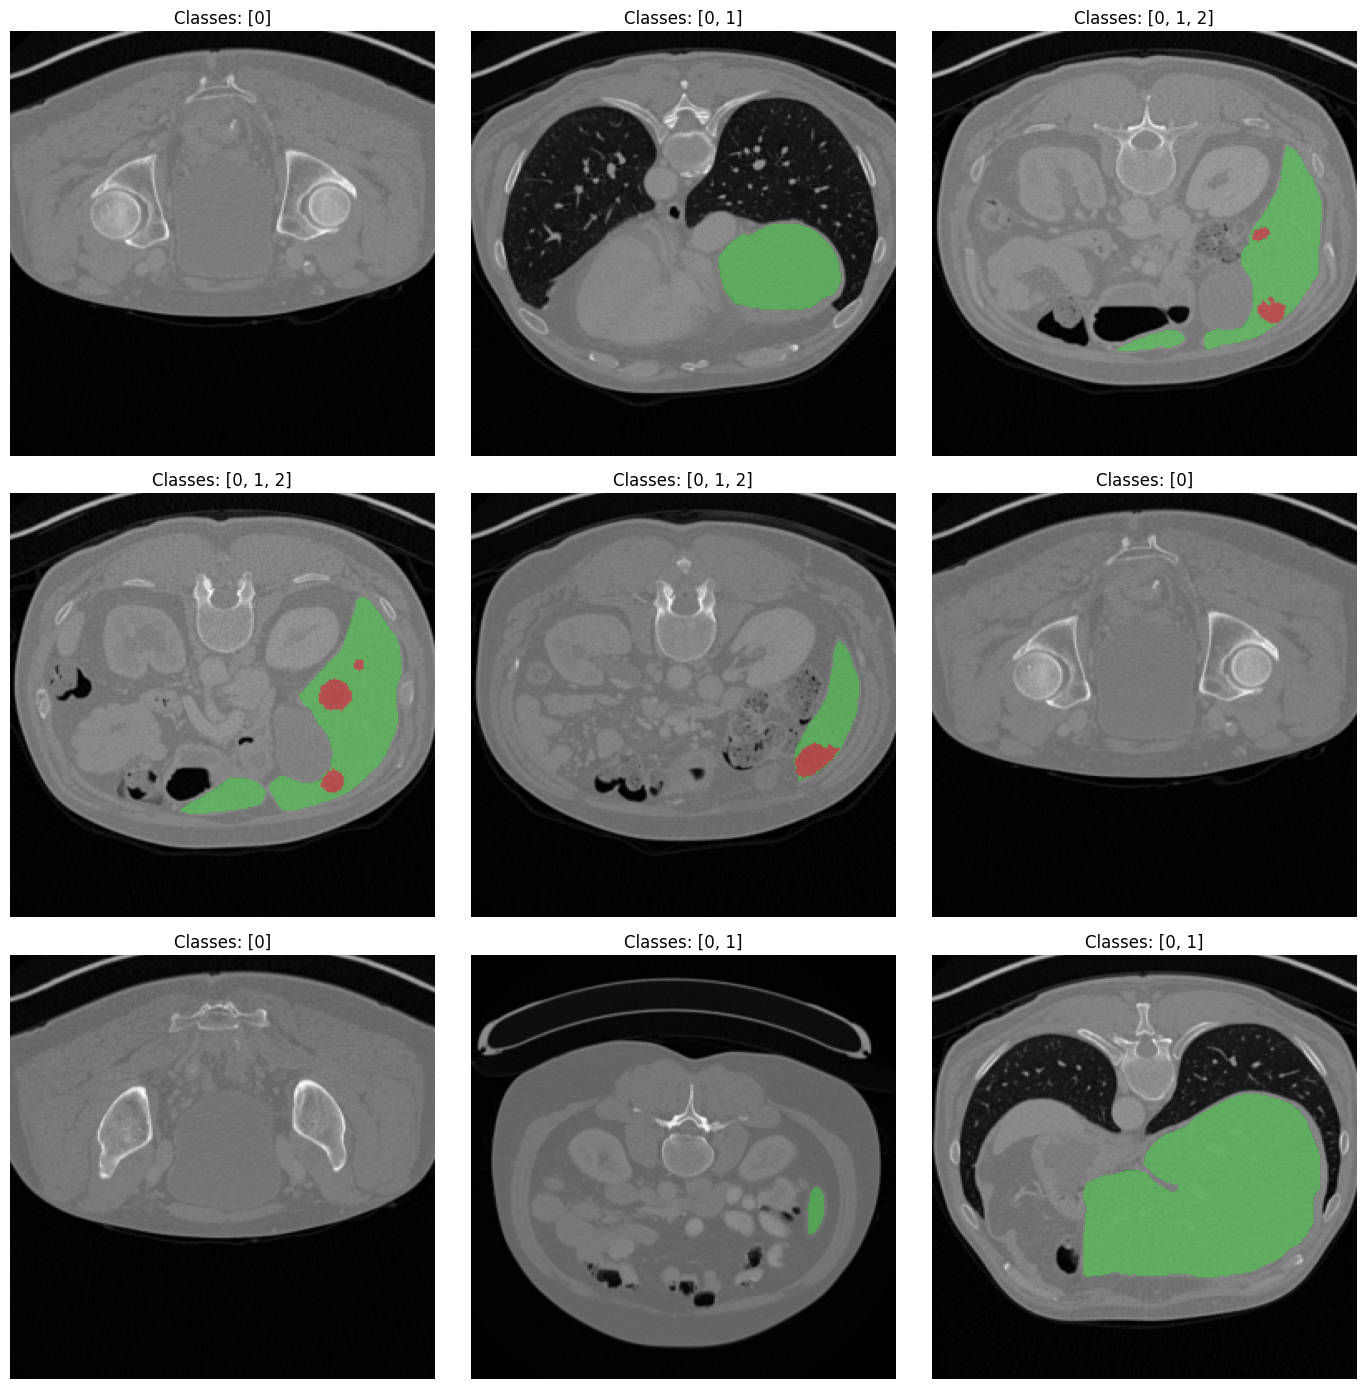

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import random

def create_overlay(image, c_target):
    """
    image: Tensor (1,H,W)
    c_target: Tensor (H,W)
    returns: (H,W,3) grayscale + (H,W,4) overlay mask
    """
    img_np = image.squeeze().cpu().numpy()
    img_rgb = np.stack([img_np]*3, axis=-1)

    h, w = c_target.shape
    mask = np.zeros((h, w, 4), dtype=np.float32)

    mask[c_target == 1] = [0, 1, 0, 0.3]

    mask[c_target == 2] = [1, 0, 0, 0.4]

    return img_rgb, mask

no_liver = []
only_liver = []
tumor = []

for img_batch, c_batch, oh_batch in debug_loader:
    for img, c in zip(img_batch, c_batch):

        classes = c.unique().tolist()

        if 2 in classes:
            if len(tumor) < 100:
                tumor.append((img, c))
                print(f"Tumor {len(tumor)}")

        elif 1 in classes:
            if len(only_liver) < 100:
                only_liver.append((img, c))
                print(f"Liver {len(only_liver)}")

        else:
            if len(no_liver) < 100:
                no_liver.append((img, c))
                print(f"Nothing {len(no_liver)}")

        if len(no_liver) == len(only_liver) == len(tumor) == 100:
            print("Stopping...")
            break

    if len(no_liver) == len(only_liver) == len(tumor) == 100:
            print("Stopping...")
            break

no_liver_samples = random.sample(no_liver, 3)
only_liver_samples = random.sample(only_liver, 3)
tumor_samples = random.sample(tumor, 3)

# jetzt erst zusammenfügen
all_samples = no_liver_samples + only_liver_samples + tumor_samples
random.shuffle(all_samples)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))

for idx, ax in enumerate(axes.flatten()):
    print("Ploting...")
    img, c = all_samples[idx]
    img_rgb, mask = create_overlay(img, c)

    ax.imshow(img_rgb, cmap="gray")
    ax.imshow(mask)
    ax.axis("off")

    unique_classes = c.unique().tolist()
    ax.set_title(f"Classes: {unique_classes}")

plt.tight_layout()
plt.show()


**Task 3 (2 points)**: Next, we need a different loss function. At the bottom, we provide a training/testing loop that already contains cross-entropy loss and a functional segmentation model, plus evaluation. We have learned in the lecture that DICE score, and by extension a DICE-based loss, can be useful for imbalanced classes. We have also discovered that LiTS 2017 contains a class imbalance - slices with tumors are much more rare than slices with livers. Hence, we will make our own DICE loss.

The formula for the DICE loss is computed as follows: $1 - \frac{2 * (|X \land Y|)+\epsilon}{|X|+|Y|+\epsilon}$, where $X$ is the prediction and $Y$ the target.

The DICE Loss class you create should fulfill the following criteria:
- It subclasses torch.nn.module.
- It is a class that implements an \_\_init\_\_ function.
- The loss also implements a \_\_forward\_\_ function that accepts as inputs a prediction tensor and a target tensor, both of shape B x 3 x 256 x 256 - 3 channels because we will segment background, liver, and liver+tumor again. The output is the computed loss.
- You may add class weighting to offset the class imbalance.

Your total loss should be `total_loss = ce_loss + dice_loss`, and your backward pass should be `total_loss.backward()`.
Run the training for a few epochs, once with and once without DICE loss included as part of the overall loss. In your experiment, which version worked better?

In [5]:
import torch, torch.nn as nn, torch.nn.functional as nnf

def compute_dice_score(prediction: torch.Tensor, target: torch.Tensor):

    """
    Computes the dice score for one class.
    """

    prediction = prediction.to(dtype = torch.bool)
    target = target.to(dtype = torch.bool)

    intersection = torch.sum(prediction * target)   # TP
    p_cardinality = torch.sum(prediction)           # TP+FP
    t_cardinality = torch.sum(target)               # TP+FN
    cardinality = p_cardinality + t_cardinality
    eps = 1e-8

    if cardinality != 0:
        dice = (2 * intersection + eps) / (cardinality + eps) # 2*TP / (2*TP+FP+FN + eps)
    else:
        dice = None

    return dice

class BinaryDiceLoss(nn.Module):
    """
    Computes Dice loss for a single class.
    Ignores slices where both prediction and target are empty.
    """
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, prediction: torch.Tensor, target: torch.Tensor):
        # prediction: (B, H, W) probabilities
        # target: (B, H, W) one-hot
        pred_flat = prediction.reshape(prediction.size(0), -1)
        tgt_flat = target.reshape(target.size(0), -1)

        intersection = (pred_flat * tgt_flat).sum(dim=1)
        denominator = pred_flat.sum(dim=1) + tgt_flat.sum(dim=1)

        # Mask für gültige Slices (wo denominator > 0)
        valid_mask = denominator > 0
        if valid_mask.sum() == 0:
            # Wenn keine gültigen Slices, return 0
            return torch.tensor(0., device=prediction.device)

        dice = (2 * intersection[valid_mask] + self.eps) / (denominator[valid_mask] + self.eps)
        loss = 1 - dice.mean()
        return loss


class DiceLoss(nn.Module):
    """
    Computes Dice loss over all classes.
    Expects:
    - predictions: (B, C, H, W) after softmax
    - targets:     (B, C, H, W) one-hot
    """
    def __init__(self, num_classes: int = 3, class_weights=None):
        super().__init__()
        self.num_classes = num_classes
        self.binary_dice = BinaryDiceLoss()

        if class_weights is None:
            self.class_weights = torch.ones(num_classes)
        else:
            self.class_weights = torch.tensor(class_weights, dtype=torch.float32)

    def forward(self, predictions: torch.Tensor, targets: torch.Tensor):
        losses = []
        for c in range(self.num_classes):
            pred_c = predictions[:, c, :, :]
            tgt_c = targets[:, c, :, :]
            loss_c = self.binary_dice(pred_c, tgt_c)
            loss_c = self.class_weights[c].to(predictions.device) * loss_c
            losses.append(loss_c)
        return torch.stack(losses).mean()



**Task 4 (4 points)**: Finally, we want to make our own model that can handle segmentations. For this course, we will build ourselves a U-Net. The original paper can be found here: https://arxiv.org/pdf/1505.04597.

The input dimensions for the network will be the usual B x 1 x 256 x 256. The output dimensions should be B x 3 x 256 x 256. We have three output channels because we will still predict classes 0 (background), 1 (liver) and 2 (liver tumor) - this time, however, we predict the classes on a per-pixel basis.

Since our input images have vastly smaller dimensions compared to those used in the original UNet-Paper, we will opt for a different scale of UNet. The general design remains the same as in the paper, except:

- We will only downsample 3 times by a factor of 2, using MaxPool (for a minimum resolution 32x32).
- Our 3x3 Convolutions will have Padding. Consequently, there will be no cropping during skip connections
- We will only have 3 skip connections.
- We will go for fewer maximum channels (as we have only 3 downsampling steps, we will have 64, 128, 256, and 512 channels).
- Our final output will be 3 channels wide, not 2 (we predict background, liver, and liver tumors).

Note that training a segmentation models takes a little while - we do not award points for results here, because it would mean that you would have to wait a long time to see whether your changes helped performance. All we want to see is that your model learns anything useful at all. As a rough guideline, you will probably start seeing ok liver segmentations after 1 epoch, and good liver and ok lesion segmentations after 2 or 3 epochs.

If everything works correctly, you can copy the previous training loop and should get some good results. Don't forget to look at some of your predictions! Are they reasonable? Empty? Weird? Can you discover some kind of systemic issues with your predictions?

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=3, features = [64, 128, 256]):
        super(UNet, self).__init__()
        self.down = nn.ModuleList()
        self.up = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.down.append(DoubleConv(in_channels, feature))
            in_channels = feature

        for feature in reversed(features):
            self.up.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.up.append(DoubleConv(feature*2, feature))

        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        self.final = nn.Conv2d(features[0], num_classes, kernel_size=1)

    def forward(self,x):
            skip_connections = []

            for down in self.down:
                x = down(x)
                skip_connections.append(x)
                x = self.pool(x)

            x = self.bottleneck(x)
            skip_connections = skip_connections[::-1]

            for idx in range(0, len(self.up), 2):
                x = self.up[idx](x)
                skip = skip_connections[idx//2]
                concat = torch.cat([skip, x], dim=1)
                x = self.up[idx+1](concat)

            return self.final(x)

In [7]:
device = ("cuda" if torch.cuda.is_available() else "cpu")

model = UNet() # Your model class goes here
model = model.to(device)

dice_loss = DiceLoss(num_classes = 3, class_weights=[1.0, 5, 20]) # Your dice loss class goes here
ce_loss = nn.CrossEntropyLoss(
    weight = torch.tensor([1.0, 5, 20]).to(device = device),
    reduction = "mean",
    #ignore_index = 0
    )

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-4)

In [9]:
from tqdm.auto import tqdm

num_epochs = 4
avg_liver_dice = 0
avg_lesion_dice = 0
dice_weight = 1
ce_weight = 1



for epoch in range(num_epochs):

    for step, (data, c_targets, oh_targets) in enumerate(train_dataloader):

        optimizer.zero_grad()
        data, c_targets, oh_targets = data.to(device), c_targets.to(device), oh_targets.to(device)
        predictions = model(data)

        pred_soft = torch.softmax(predictions, dim=1)
        loss_1 = dice_loss(pred_soft , oh_targets)
        loss_2 = ce_loss(predictions, c_targets)
        total_loss = loss_1 * dice_weight + loss_2 * ce_weight # We could weight contributions from the different loss components here, although 1-to-1 should do just fine

        if step % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]\t Step [{step+1}/{len(train_dataloader.dataset)//batch_size}]\t Loss: {total_loss.item():.4f}")

        total_loss.backward()
        optimizer.step()

        # Validate once after every epoch
    model.eval()

        # Don't track gradients for validation
    with torch.no_grad():

            losses = []
            background_dices = []
            background_counts = []
            liver_dices = []
            liver_counts = []
            lesion_dices = []
            lesion_counts = []
            batch_sizes = []

            for val_step, (data, c_targets, oh_targets) in enumerate(tqdm(val_dataloader)):

                data, c_targets, oh_targets = data.to(device), c_targets.to(device), oh_targets.to(device)
                predictions = model(data)
                # Choose the likeliest prediction via argmax, then convert to one-hot, and put the new axis in front again
                p_arg = nnf.one_hot(torch.argmax(predictions, dim = 1), num_classes = 3).moveaxis(-1, 1)

                # loss
                loss_1 = dice_loss(predictions, oh_targets)
                loss_2 = ce_loss(predictions, c_targets)
                total_loss = loss_1 * dice_weight + loss_2 * ce_weight # We could weight contributions from the different loss components here, although 1-to-1 should do just fine

                losses.append(total_loss.item())
                batch_sizes.append(data.size()[0])

                background_seg = oh_targets[:, 0, :, :]
                liver_seg = oh_targets[:, 1, :, :]
                lesion_seg = oh_targets[:, 2, :, :]

                background_dice = compute_dice_score(p_arg[:,0,:,:], background_seg)
                background_counts.append(data.size()[0])
                background_dices.append(background_dice)

                if liver_seg.sum() != 0.0:
                    liver_dice = compute_dice_score(p_arg[:,1,:,:], liver_seg)
                    liver_counts.append(data.size()[0])
                    liver_dices.append(liver_dice)

                if lesion_seg.sum() != 0.0:
                    lesion_dice = compute_dice_score(p_arg[:,2,:,:], lesion_seg)
                    lesion_counts.append(data.size()[0])
                    lesion_dices.append(lesion_dice)

            print(liver_dices)
            print(liver_counts)
            avg_background_dice = sum([dice * size for dice, size in zip(background_dices, background_counts)])/sum(background_counts)

            avg_liver_dice = sum([dice * size for dice, size in zip(liver_dices, liver_counts)])/sum(liver_counts)
            avg_lesion_dice = sum([dice * size for dice, size in zip(lesion_dices, lesion_counts)])/sum(lesion_counts)

            avg_loss = sum([l * bs for l, bs in zip(losses, background_counts)]) / sum(background_counts)
            print(f"Epoch: {epoch+1},\t Validation Loss: {avg_loss},\t Liver Dice Score: {avg_liver_dice}, \t Lesion Dice Score: {avg_lesion_dice}")

            # After we are done validating, let's not forget to go back to storing gradients.
            model.train()


Epoch [1/4]	 Step [1/2534]	 Loss: 8.6428
Epoch [1/4]	 Step [11/2534]	 Loss: 8.6927
Epoch [1/4]	 Step [21/2534]	 Loss: 8.8203
Epoch [1/4]	 Step [31/2534]	 Loss: 8.7531
Epoch [1/4]	 Step [41/2534]	 Loss: 8.5405
Epoch [1/4]	 Step [51/2534]	 Loss: 8.7112
Epoch [1/4]	 Step [61/2534]	 Loss: 8.5825
Epoch [1/4]	 Step [71/2534]	 Loss: 8.5333
Epoch [1/4]	 Step [81/2534]	 Loss: 8.5475
Epoch [1/4]	 Step [91/2534]	 Loss: 8.5752
Epoch [1/4]	 Step [101/2534]	 Loss: 8.5603
Epoch [1/4]	 Step [111/2534]	 Loss: 8.3731
Epoch [1/4]	 Step [121/2534]	 Loss: 8.5341
Epoch [1/4]	 Step [131/2534]	 Loss: 8.4902
Epoch [1/4]	 Step [141/2534]	 Loss: 8.2851
Epoch [1/4]	 Step [151/2534]	 Loss: 8.5497
Epoch [1/4]	 Step [161/2534]	 Loss: 8.3600
Epoch [1/4]	 Step [171/2534]	 Loss: 8.3781
Epoch [1/4]	 Step [181/2534]	 Loss: 8.4080
Epoch [1/4]	 Step [191/2534]	 Loss: 8.3301
Epoch [1/4]	 Step [201/2534]	 Loss: 8.3322
Epoch [1/4]	 Step [211/2534]	 Loss: 8.4255
Epoch [1/4]	 Step [221/2534]	 Loss: 8.3788
Epoch [1/4]	 Step [231

100%|██████████| 217/217 [00:27<00:00,  7.89it/s]


[tensor(0.8735, device='cuda:0'), tensor(0.8141, device='cuda:0'), tensor(0.9156, device='cuda:0'), tensor(0.9088, device='cuda:0'), tensor(0.8410, device='cuda:0'), tensor(0.9112, device='cuda:0'), tensor(0.8299, device='cuda:0'), tensor(0.9399, device='cuda:0'), tensor(0.9064, device='cuda:0'), tensor(0.8773, device='cuda:0'), tensor(0.9288, device='cuda:0'), tensor(0.8780, device='cuda:0'), tensor(0.8312, device='cuda:0'), tensor(0.8459, device='cuda:0'), tensor(0.9328, device='cuda:0'), tensor(0.8749, device='cuda:0'), tensor(0.6681, device='cuda:0'), tensor(0.9255, device='cuda:0'), tensor(0.8975, device='cuda:0'), tensor(0.8544, device='cuda:0'), tensor(0.9175, device='cuda:0'), tensor(0.9244, device='cuda:0'), tensor(0.9149, device='cuda:0'), tensor(0.9377, device='cuda:0'), tensor(0.9121, device='cuda:0'), tensor(0.3693, device='cuda:0'), tensor(0.6526, device='cuda:0'), tensor(0.5541, device='cuda:0'), tensor(0.7173, device='cuda:0'), tensor(0.4980, device='cuda:0'), tensor(0.

100%|██████████| 217/217 [00:25<00:00,  8.36it/s]


[tensor(0.7004, device='cuda:0'), tensor(0.6455, device='cuda:0'), tensor(0.7055, device='cuda:0'), tensor(0.7242, device='cuda:0'), tensor(0.6763, device='cuda:0'), tensor(0.5089, device='cuda:0'), tensor(0.7843, device='cuda:0'), tensor(0.7688, device='cuda:0'), tensor(0.5927, device='cuda:0'), tensor(0.6646, device='cuda:0'), tensor(0.6669, device='cuda:0'), tensor(0.5173, device='cuda:0'), tensor(0.6166, device='cuda:0'), tensor(0.6969, device='cuda:0'), tensor(0.4864, device='cuda:0'), tensor(0.7609, device='cuda:0'), tensor(0.7061, device='cuda:0'), tensor(0.6499, device='cuda:0'), tensor(0.7066, device='cuda:0'), tensor(0.4600, device='cuda:0'), tensor(0.5400, device='cuda:0'), tensor(0.8118, device='cuda:0'), tensor(0.7846, device='cuda:0'), tensor(0.7272, device='cuda:0'), tensor(0.6075, device='cuda:0'), tensor(0.5486, device='cuda:0'), tensor(0.7219, device='cuda:0'), tensor(0.5384, device='cuda:0'), tensor(0.7379, device='cuda:0'), tensor(0.7300, device='cuda:0'), tensor(0.

100%|██████████| 217/217 [00:26<00:00,  8.33it/s]


[tensor(0.9711, device='cuda:0'), tensor(0.8718, device='cuda:0'), tensor(0.8853, device='cuda:0'), tensor(0.9525, device='cuda:0'), tensor(0.9250, device='cuda:0'), tensor(0.8917, device='cuda:0'), tensor(0.9615, device='cuda:0'), tensor(0.6718, device='cuda:0'), tensor(0.9379, device='cuda:0'), tensor(0.8039, device='cuda:0'), tensor(0.8380, device='cuda:0'), tensor(0.8819, device='cuda:0'), tensor(0.9553, device='cuda:0'), tensor(0.7428, device='cuda:0'), tensor(0.8888, device='cuda:0'), tensor(0.9543, device='cuda:0'), tensor(0.8255, device='cuda:0'), tensor(0.8441, device='cuda:0'), tensor(0.9272, device='cuda:0'), tensor(0.9604, device='cuda:0'), tensor(0.9132, device='cuda:0'), tensor(0.8166, device='cuda:0'), tensor(0.8382, device='cuda:0'), tensor(0.9328, device='cuda:0'), tensor(0.9276, device='cuda:0'), tensor(0.8924, device='cuda:0'), tensor(0.9430, device='cuda:0'), tensor(0.9507, device='cuda:0'), tensor(0.7711, device='cuda:0'), tensor(0.9211, device='cuda:0'), tensor(0.

100%|██████████| 217/217 [00:26<00:00,  8.34it/s]


[tensor(0.8725, device='cuda:0'), tensor(0.8512, device='cuda:0'), tensor(0.8683, device='cuda:0'), tensor(0.9243, device='cuda:0'), tensor(0.4989, device='cuda:0'), tensor(0.9389, device='cuda:0'), tensor(0.8805, device='cuda:0'), tensor(0.8910, device='cuda:0'), tensor(0.9292, device='cuda:0'), tensor(0.8895, device='cuda:0'), tensor(0.9238, device='cuda:0'), tensor(0.7633, device='cuda:0'), tensor(0.9154, device='cuda:0'), tensor(0.9447, device='cuda:0'), tensor(0.9235, device='cuda:0'), tensor(0.8286, device='cuda:0'), tensor(0.8406, device='cuda:0'), tensor(0.0109, device='cuda:0'), tensor(0.8539, device='cuda:0'), tensor(0.9084, device='cuda:0'), tensor(0.8838, device='cuda:0'), tensor(0.9574, device='cuda:0'), tensor(0.7944, device='cuda:0'), tensor(0.8158, device='cuda:0'), tensor(0.7775, device='cuda:0'), tensor(0.8897, device='cuda:0'), tensor(0.8828, device='cuda:0'), tensor(0.7358, device='cuda:0'), tensor(0.9369, device='cuda:0'), tensor(0.9240, device='cuda:0'), tensor(0.

In [10]:
model.eval()

# Don't track gradients for testing
with torch.no_grad():

    losses = []
    background_dices = []
    background_counts = []
    liver_dices = []
    liver_counts = []
    lesion_dices = []
    lesion_counts = []
    batch_sizes = []

    for test_step, (data, c_targets, oh_targets) in enumerate(tqdm(test_dataloader)):

        data, c_targets, oh_targets = data.to(device), c_targets.to(device), oh_targets.to(device)
        predictions = model(data)
        # Choose the likeliest prediction via argmax, then convert to one-hot, and put the new axis in front again
        p_arg = nnf.one_hot(torch.argmax(predictions, dim = 1), num_classes = 3).moveaxis(-1, 1)

        # loss
        loss_1 = dice_loss(predictions, oh_targets)
        loss_2 = ce_loss(predictions, c_targets)
        total_loss = loss_1 * dice_weight + loss_2 * ce_weight # We could weight contributions from the different loss components here, although 1-to-1 should do just fine

        losses.append(total_loss.item())
        batch_sizes.append(data.size()[0])

        background_seg = oh_targets[:, 0, :, :]
        liver_seg = oh_targets[:, 1, :, :]
        lesion_seg = oh_targets[:, 2, :, :]

        background_dice = compute_dice_score(p_arg[:,0,:,:], background_seg)
        background_counts.append(data.size()[0])
        background_dices.append(background_dice)

        if liver_seg.sum() != 0.0:
            liver_dice = compute_dice_score(p_arg[:,1,:,:], liver_seg)
            liver_counts.append(data.size()[0])
            liver_dices.append(liver_dice)

        if lesion_seg.sum() != 0.0:
            lesion_dice = compute_dice_score(p_arg[:,2,:,:], lesion_seg)
            lesion_counts.append(data.size()[0])
            lesion_dices.append(lesion_dice)

    avg_background_dice = sum([dice * size for dice, size in zip(background_dices, background_counts)])/sum(background_counts)
    avg_liver_dice = sum([dice * size for dice, size in zip(liver_dices, liver_counts)])/sum(liver_counts)
    avg_lesion_dice = sum([dice * size for dice, size in zip(lesion_dices, lesion_counts)])/sum(lesion_counts)

    avg_loss = sum([l * bs for l, bs in zip(losses, background_counts)]) / sum(background_counts)
    print(f"Epoch: {epoch+1},\t Test Loss: {avg_loss:.4f},\t Liver Dice Score: {avg_liver_dice:.4f}, \t Lesion Dice Score: {avg_lesion_dice:.4f}")

100%|██████████| 217/217 [00:26<00:00,  8.33it/s]

Epoch: 4,	 Test Loss: -0.1642,	 Liver Dice Score: 0.8884, 	 Lesion Dice Score: 0.6156


IndexError: index 40 is out of bounds for axis 0 with size 40

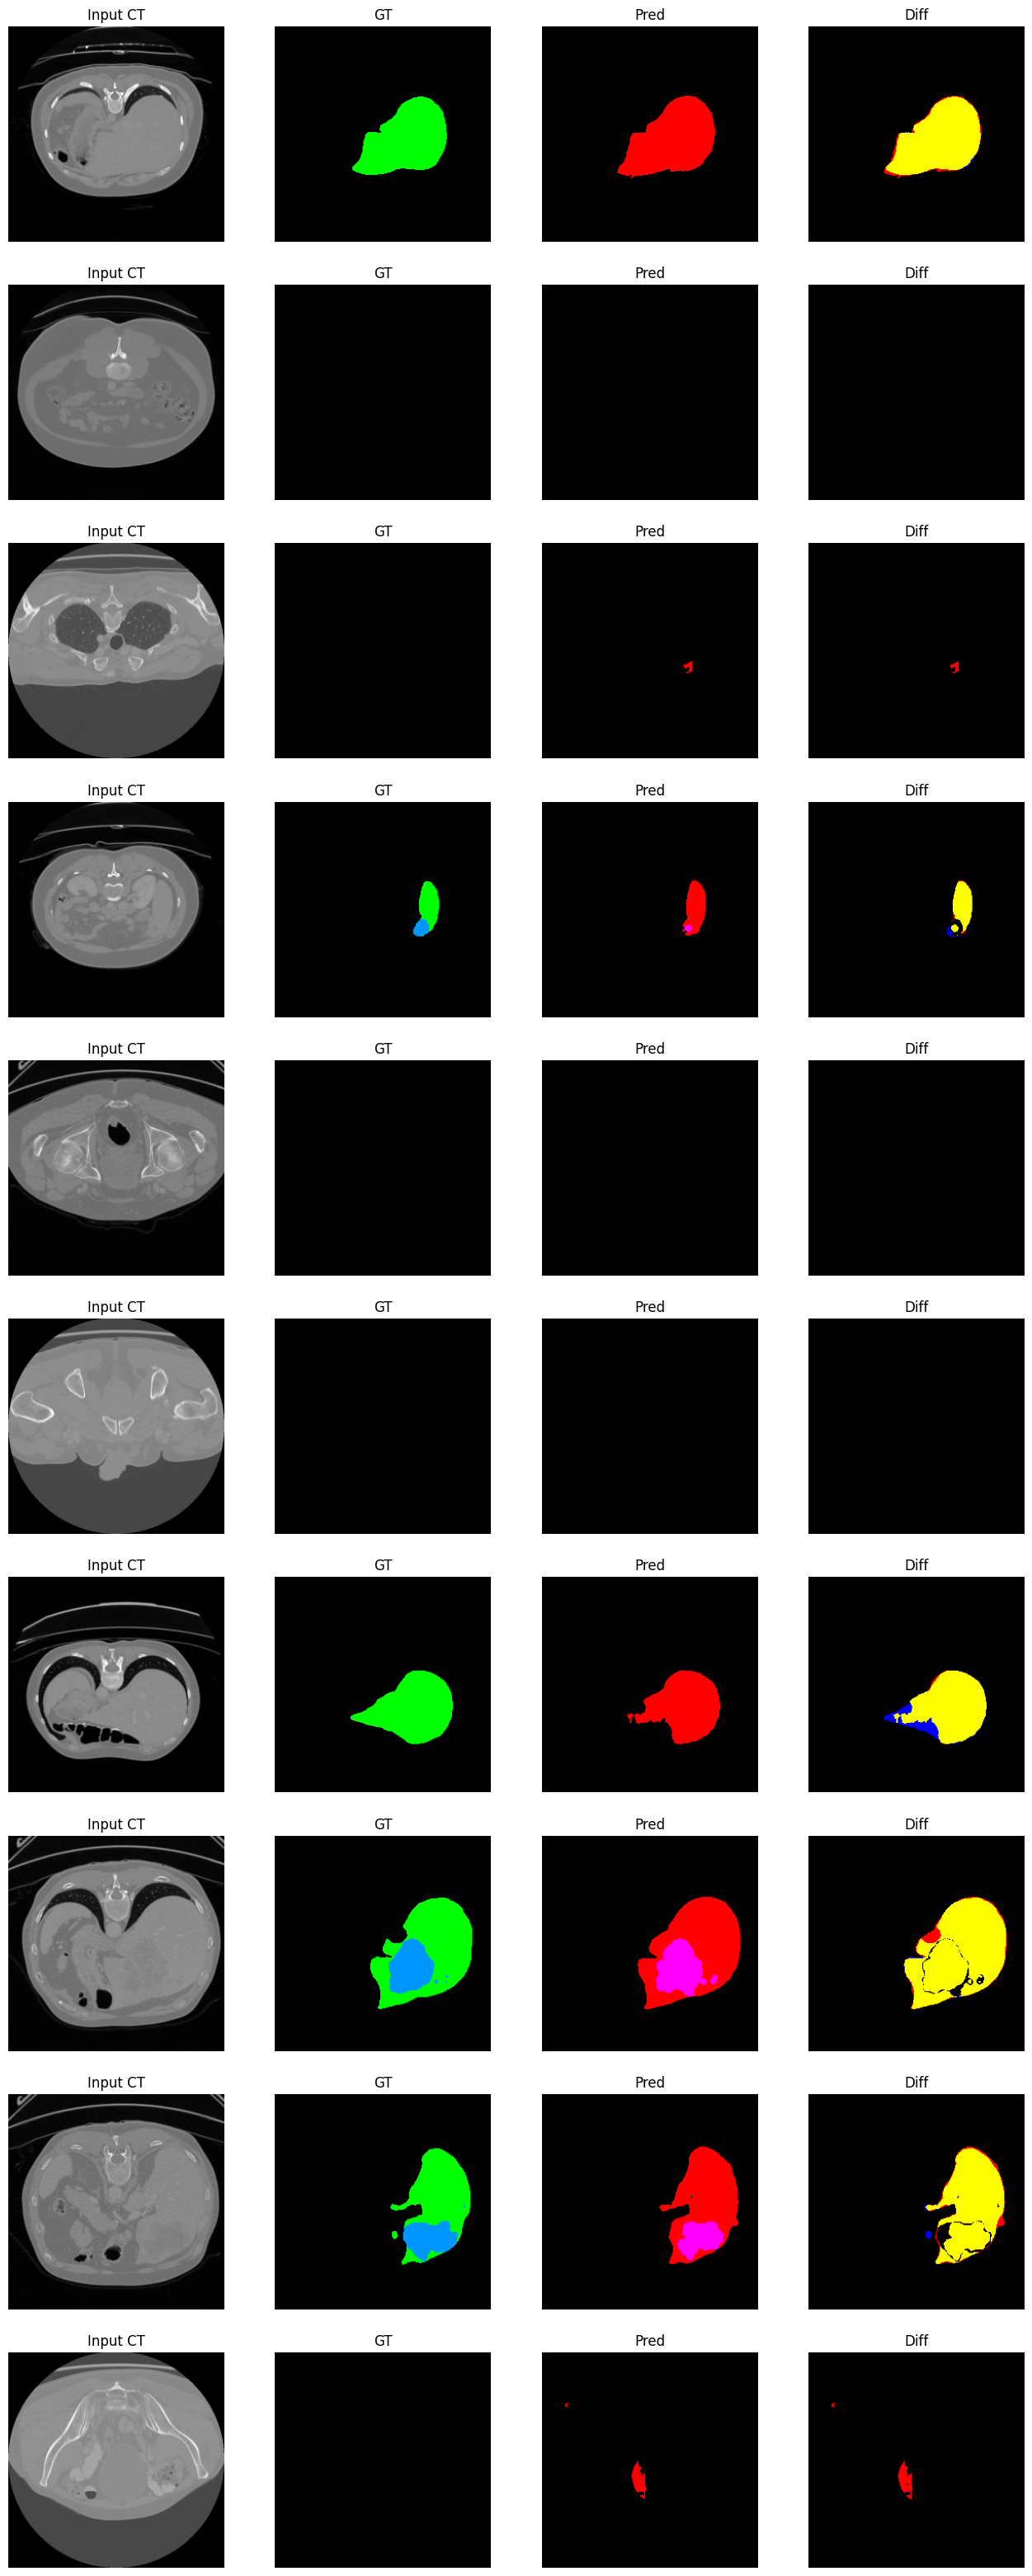

In [15]:
# Try looking at some images and predicted segmentations to see how badly or how well you've done

import matplotlib.pyplot as plt
import numpy as np

def colorize_masks(gt, pred):
    """
    gt:   (H,W) ints {0,1,2}
    pred: (H,W) ints {0,1,2}

    Output: 3 RGB-Bilder
    """
    H, W = gt.shape

    gt_rgb   = np.zeros((H,W,3), dtype=np.uint8)
    pred_rgb = np.zeros((H,W,3), dtype=np.uint8)
    diff_rgb = np.zeros((H,W,3), dtype=np.uint8)

    # ========== GROUND TRUTH ==========
    gt_rgb[gt == 1] = [0, 255, 0]     # liver green
    gt_rgb[gt == 2] = [0, 150, 255]   # tumor blue

    # ========== PREDICTION ==========
    pred_rgb[pred == 1] = [255, 0, 0]   # liver red
    pred_rgb[pred == 2] = [255, 0, 255] # tumor purple

    # ========== DIFFERENCE MAP ==========
    # correct = yellow
    match = (gt == pred) & (gt != 0)
    diff_rgb[match] = [255, 255, 0]

    # false positives = red
    fp = (gt == 0) & (pred != 0)
    diff_rgb[fp] = [255, 0, 0]

    # false negatives = blue
    fn = (gt != 0) & (pred == 0)
    diff_rgb[fn] = [0, 0, 255]

    return gt_rgb, pred_rgb, diff_rgb


# ========== PLOT 9 EXAMPLES ==========
import math

model.eval()
num_examples = 3
batch_plot = 1  # wie viele Bilder gleichzeitig pro Plot (hier 1 pro Schritt)
cols = 4
rows = 10  # 10x4 = 40 Bilder pro Seite, dann mehrere Seiten

counter = 0
page = 1

with torch.no_grad():
    for data, c_targets, oh_targets in test_dataloader:

        data = data.to(device)
        preds = model(data)
        preds_arg = torch.argmax(preds, dim=1).cpu()

        batch_size = data.size(0)
        for i in range(batch_size):

            img = data.cpu()[i,0,:,:].numpy()
            gt  = c_targets[i].cpu().numpy()
            pred = preds_arg[i].numpy()

            gt_rgb, pred_rgb, diff_rgb = colorize_masks(gt, pred)

            if counter % (rows*cols) == 0:
                # neue Seite
                fig, axes = plt.subplots(rows, cols, figsize=(16, 40))
                axes = axes.flatten()

            axes[(counter % (rows*cols))*4 + 0].imshow(img, cmap="gray")
            axes[(counter % (rows*cols))*4 + 0].set_title("Input CT")
            axes[(counter % (rows*cols))*4 + 0].axis("off")

            axes[(counter % (rows*cols))*4 + 1].imshow(gt_rgb)
            axes[(counter % (rows*cols))*4 + 1].set_title("GT")
            axes[(counter % (rows*cols))*4 + 1].axis("off")

            axes[(counter % (rows*cols))*4 + 2].imshow(pred_rgb)
            axes[(counter % (rows*cols))*4 + 2].set_title("Pred")
            axes[(counter % (rows*cols))*4 + 2].axis("off")

            axes[(counter % (rows*cols))*4 + 3].imshow(diff_rgb)
            axes[(counter % (rows*cols))*4 + 3].set_title("Diff")
            axes[(counter % (rows*cols))*4 + 3].axis("off")

            counter += 1
            if counter >= num_examples:
                break

            # neue Seite anzeigen
            if counter % (rows*cols) == 0:
                plt.tight_layout()
                plt.show()
                page += 1

    # letzte Seite anzeigen, falls unvollständig
    if counter % (rows*cols) != 0:
        plt.tight_layout()
        plt.show()